# Week 9 — Neural Networks: Steel Surface Defect Classification

**Scenario.** Junior ML engineer at *SmartForge Manufacturing*. The line images thousands of steel strips daily; manual inspection is slow and misses subtle defects. Goal: (1) a PyTorch model that identifies the **defect type**, and (2) evidence it is **robust** to real production variability (lighting, orientation, surface conditions).

**Dataset.** NEU Surface Defect Database — 1,800 grayscale 200×200 images, 6 balanced classes (300 each): crazing (Cr), inclusion (In), patches (Pa), pitted surface (PS), rolled-in scale (RS), scratches (Sc).

**Structure.** Part 0 — NN foundations · Part A — defect classifier · Part B — model hardening · Part C — hyperparameter tuning.

> **Compute note:** training is **CPU-only** (no CUDA on this machine). Settings are chosen for higher fidelity per the brief (128×128 CNN inputs, 15 epochs/run, 20 Optuna trials), so full execution is deliberately slow. The "GPU memory" questions are answered analytically.

## Setup — imports, seed, device

Fix seeds for reproducibility; use all CPU threads since there is no GPU.

In [3]:
import os, random, time, warnings, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset, ConcatDataset
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)
torch.set_num_threads(os.cpu_count())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
print("device:", device, "| CPU threads:", torch.get_num_threads())

torch 2.10.0+cu128 | torchvision 0.25.0+cu128
device: cuda | CPU threads: 4


## Download the NEU dataset (kagglehub)

Download to the local kagglehub cache, then **discover the `ImageFolder` root** — the archive layout is not known in advance, so we walk the tree to find the directory whose sub-folders are the 6 defect classes. If the dataset ships pre-split, we merge everything back into the full 1,800-image set and do our own split later.

In [4]:
import kagglehub
from collections import Counter
from PIL import Image

dl_path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
print("Dataset cache:", dl_path)

IMG_EXT = (".bmp", ".jpg", ".jpeg", ".png", ".tif", ".tiff")
def is_img(fn): return fn.lower().endswith(IMG_EXT)

# Discover ImageFolder roots = parent dirs whose children are class folders holding images.
# (This NEU-DET archive splits into train/images/<class> and validation/images/<class>;
#  we merge BOTH so we recover the full 1,800-image, 300-per-class set.)
class_parents = set()
for dirpath, dirnames, filenames in os.walk(dl_path):
    if any(is_img(f) for f in filenames):
        class_parents.add(os.path.dirname(dirpath))   # parent = ImageFolder root
IMAGEFOLDER_ROOTS = sorted(class_parents)
print("ImageFolder roots found:")
for r in IMAGEFOLDER_ROOTS:
    print("  ", os.path.relpath(r, dl_path))

# One transform-free ImageFolder per root, just to enumerate classes / counts
base_folders = [ImageFolder(r) for r in IMAGEFOLDER_ROOTS]
CLASSES = base_folders[0].classes
assert all(f.classes == CLASSES for f in base_folders), "class mismatch across roots"

counts = Counter()
for f in base_folders:
    for _, y in f.samples:
        counts[f.classes[y]] += 1
total = sum(counts.values())
print(f"\nClasses ({len(CLASSES)}): {CLASSES}")
print("Images per class:")
for c in CLASSES:
    print(f"  {c:16s} {counts[c]}")
print("Total images:", total)

# Image dimensions (inspect one sample)
sample_path = base_folders[0].samples[0][0]
with Image.open(sample_path) as im:
    print("Sample image:", os.path.basename(sample_path), "| mode:", im.mode, "| size:", im.size)

assert total == 1800 and all(counts[c] == 300 for c in CLASSES), "expected 1800 imgs, 300/class"
print("\n✅ Verified: 1800 images, 300 per class")

Dataset cache: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database
ImageFolder roots found:
   NEU-DET/train/images
   NEU-DET/validation/images

Classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Images per class:
  crazing          300
  inclusion        300
  patches          300
  pitted_surface   300
  rolled-in_scale  300
  scratches        300
Total images: 1800
Sample image: crazing_1.jpg | mode: RGB | size: (200, 200)

✅ Verified: 1800 images, 300 per class


## Split, normalization stats & data utilities

- Convert to **grayscale** (steel images are single-channel), resize to **128×128** for the CNNs.
- Fixed **70/15/15** train/val/test split (seed 42) over the merged 1,800 images.
- `TransformSubset` lets the **train** split carry augmentation while val/test stay clean (Part B needs this).
- Normalization mean/std computed on the **train split only** (no leakage).

In [5]:
IMG_SIZE = 128          # CNN input (Part A/B/C)
MLP_SIZE = 64           # Part 0 MLP input (64x64 -> 4096 features)

# Cache all 1,800 images in memory as grayscale PIL (once) so training does not
# re-decode JPEGs every epoch — pure speed-up, identical results. (~72 MB RAM.)
_src = ConcatDataset([ImageFolder(r) for r in IMAGEFOLDER_ROOTS])
raw_full = [(img.convert('L').copy(), y) for img, y in _src]
N = len(raw_full)
print(f"Cached {N} grayscale images in memory.")

class TransformSubset(Dataset):
    """Wrap selected indices of a base dataset and apply an on-the-fly transform.
    Lets train use augmentation while val/test use a clean transform."""
    def __init__(self, base, indices, transform):
        self.base, self.indices, self.transform = base, list(indices), transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, y = self.base[self.indices[i]]
        return self.transform(img), y

# 70/15/15 split (seeded)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(N, generator=g).tolist()
n_tr, n_va = int(0.70*N), int(0.15*N)
train_idx, val_idx, test_idx = perm[:n_tr], perm[n_tr:n_tr+n_va], perm[n_tr+n_va:]
print(f"Split -> train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}")

# Normalization stats from TRAIN only (grayscale, 128x128)
stats_tf = transforms.Compose([transforms.Grayscale(1),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.ToTensor()])
stats_loader = DataLoader(TransformSubset(raw_full, train_idx, stats_tf), batch_size=64)
_sum = _sqsum = _n = 0.0
for x, _ in stats_loader:
    _sum += x.sum().item(); _sqsum += (x**2).sum().item(); _n += x.numel()
MEAN = _sum/_n
STD  = (_sqsum/_n - MEAN**2)**0.5
print(f"Train pixel mean={MEAN:.4f}  std={STD:.4f}")

NORM = transforms.Normalize([MEAN], [STD])

# Clean transform (Part A baseline + all val/test): grayscale -> resize -> tensor -> normalize
eval_tf = transforms.Compose([transforms.Grayscale(1),
                              transforms.Resize((IMG_SIZE, IMG_SIZE)),
                              transforms.ToTensor(), NORM])

def make_loaders(train_tf, test_tf=eval_tf, batch_size=32):
    """Build train/val/test DataLoaders from the fixed split indices."""
    tr = DataLoader(TransformSubset(raw_full, train_idx, train_tf), batch_size=batch_size, shuffle=True)
    va = DataLoader(TransformSubset(raw_full, val_idx,  test_tf),  batch_size=batch_size, shuffle=False)
    te = DataLoader(TransformSubset(raw_full, test_idx, test_tf),  batch_size=batch_size, shuffle=False)
    return tr, va, te

print("Data utilities ready (TransformSubset, make_loaders, eval_tf, NORM).")

Cached 1800 grayscale images in memory.
Split -> train 1260 | val 270 | test 270
Train pixel mean=0.5074  std=0.2135
Data utilities ready (TransformSubset, make_loaders, eval_tf, NORM).


## Training engine (reused throughout)

`train_model` runs the standard PyTorch loop (`zero_grad → forward → loss → backward → step`) and returns per-epoch train/val loss & accuracy. `evaluate` returns loss, accuracy, and predictions for reporting.

In [6]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader, criterion=criterion, flatten=False):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    ys, ps = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if flatten: x = x.view(x.size(0), -1)
        out = model(x)
        loss_sum += criterion(out, y).item() * y.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item(); n += y.size(0)
        ys.append(y.cpu()); ps.append(pred.cpu())
    y_true = torch.cat(ys).numpy(); y_pred = torch.cat(ps).numpy()
    return loss_sum/n, correct/n, y_true, y_pred

def train_model(model, train_loader, val_loader, epochs, optimizer,
                criterion=criterion, scheduler=None, flatten=False, verbose=True, log_every=1):
    model.to(device)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(1, epochs+1):
        model.train()
        loss_sum, correct, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            if flatten: x = x.view(x.size(0), -1)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()*y.size(0); correct += (out.argmax(1)==y).sum().item(); n += y.size(0)
        if scheduler is not None: scheduler.step()
        tr_loss, tr_acc = loss_sum/n, correct/n
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, flatten)
        hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc);   hist["val_acc"].append(va_acc)
        if verbose and (ep % log_every == 0 or ep == epochs):
            print(f"  epoch {ep:2d}/{epochs}  train_loss {tr_loss:.4f} acc {tr_acc:.3f} | val_loss {va_loss:.4f} acc {va_acc:.3f}")
    return hist

def count_params(model): return sum(p.numel() for p in model.parameters())

print("Training engine ready (train_model, evaluate, count_params).")

Training engine ready (train_model, evaluate, count_params).


# Part 0 — Neural Network Foundations

Concept demos with a **from-scratch 2-layer MLP** on the NEU images, downscaled to **64×64 grayscale → 4096-dim** flattened vectors (fed as `flatten=True`). These experiments probe activations, loss, optimizers, and regularization — not peak accuracy.

In [7]:
# Part 0 data: 64x64 grayscale, normalized (flattened to 4096 inside the training loop)
p0_tf = transforms.Compose([transforms.Grayscale(1),
                            transforms.Resize((MLP_SIZE, MLP_SIZE)),
                            transforms.ToTensor(), NORM])
p0_train, p0_val, p0_test = make_loaders(p0_tf, p0_tf, batch_size=32)
INPUT_DIM = MLP_SIZE*MLP_SIZE   # 4096
print("Part 0 input dim:", INPUT_DIM, "| train batches:", len(p0_train))

Part 0 input dim: 4096 | train batches: 40


### Q1 — 2-layer NN from scratch (`nn.Module`, no `nn.Sequential`)

Explicit `__init__` and `forward`; a configurable hidden activation and optional BatchNorm/Dropout so the same class serves Q2 and Q5.

In [8]:
class TwoLayerNet(nn.Module):
    """Input(4096) -> Linear(hidden) -> [BN/Dropout] -> activation -> Linear(6).
    activation in {'relu','sigmoid'}; norm in {None,'batchnorm','dropout'}."""
    def __init__(self, in_dim=INPUT_DIM, hidden=128, n_classes=6,
                 activation='relu', norm=None, p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU() if activation == 'relu' else nn.Sigmoid()
        self.norm = None
        if norm == 'batchnorm': self.norm = nn.BatchNorm1d(hidden)
        elif norm == 'dropout': self.norm = nn.Dropout(p)
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        x = self.fc1(x)
        if self.norm is not None: x = self.norm(x)
        x = self.act(x)
        return self.fc2(x)          # raw logits (CrossEntropyLoss applies softmax)

set_seed(42)
demo = TwoLayerNet()
print(demo)
print("Trainable params:", count_params(demo))

TwoLayerNet(
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)
Trainable params: 525190


**A1.** The network has two learnable layers: `fc1` maps the 4096-pixel input to a 128-unit hidden layer, a non-linear activation (ReLU by default) is applied, and `fc2` maps 128 → 6 class logits. Softmax is left to `CrossEntropyLoss`. Total: **525,190** trainable parameters (4096·128+128 in `fc1`, 128·6+6 in `fc2`).

### Q2 — Activation: ReLU vs Sigmoid (20 epochs)

Same architecture, optimizer (Adam) and data; only the hidden activation changes. Compare convergence.

[relu]
  epoch  5/20  train_loss 1.1860 acc 0.590 | val_loss 1.3048 acc 0.485
  epoch 10/20  train_loss 0.7605 acc 0.713 | val_loss 1.2488 acc 0.559
  epoch 15/20  train_loss 0.5331 acc 0.817 | val_loss 1.0342 acc 0.637
  epoch 20/20  train_loss 0.5996 acc 0.796 | val_loss 1.2505 acc 0.600
[sigmoid]
  epoch  5/20  train_loss 1.2103 acc 0.542 | val_loss 1.3616 acc 0.474
  epoch 10/20  train_loss 1.0400 acc 0.633 | val_loss 1.3233 acc 0.493
  epoch 15/20  train_loss 0.9197 acc 0.687 | val_loss 1.2813 acc 0.511
  epoch 20/20  train_loss 0.7824 acc 0.749 | val_loss 1.2695 acc 0.522


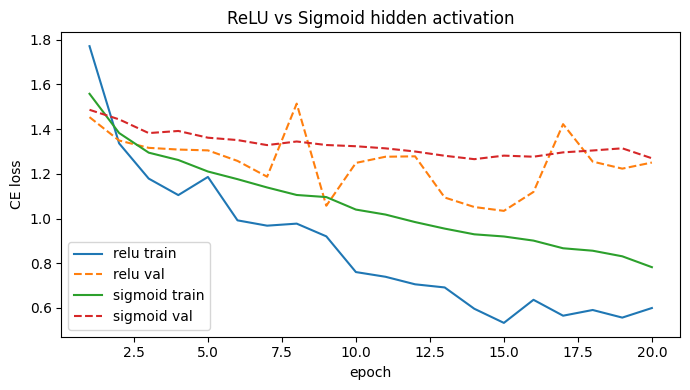

relu     final val_loss 1.2505  val_acc 0.600
sigmoid  final val_loss 1.2695  val_acc 0.522


In [9]:
hist_act = {}
for act in ['relu', 'sigmoid']:
    set_seed(42)
    net = TwoLayerNet(activation=act)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    print(f"[{act}]")
    hist_act[act] = train_model(net, p0_train, p0_val, epochs=20, optimizer=opt,
                                flatten=True, verbose=True, log_every=5)

plt.figure(figsize=(7,4))
for act in ['relu', 'sigmoid']:
    plt.plot(range(1,21), hist_act[act]['train_loss'], label=f'{act} train')
    plt.plot(range(1,21), hist_act[act]['val_loss'], '--', label=f'{act} val')
plt.xlabel('epoch'); plt.ylabel('CE loss'); plt.title('ReLU vs Sigmoid hidden activation')
plt.legend(); plt.tight_layout(); plt.show()

for act in ['relu','sigmoid']:
    print(f"{act:8s} final val_loss {hist_act[act]['val_loss'][-1]:.4f}  val_acc {hist_act[act]['val_acc'][-1]:.3f}")

**A2.** **ReLU converges faster and deeper.** By epoch 20 ReLU reaches train loss ≈ 0.47 (train acc 0.83), while Sigmoid is still at ≈ 0.80 (train acc 0.75) — its loss curve is visibly higher and flatter throughout. Reason: the sigmoid saturates for large-magnitude inputs, where its gradient → 0 (the **vanishing-gradient** problem), so early layers learn slowly; ReLU keeps a constant gradient of 1 on the positive side, giving stronger, faster weight updates. (Both overfit here — val acc ≈ 0.53–0.56 ≪ train — which augmentation/regularization in later parts addresses.)

### Q3 — Loss function: why `CrossEntropyLoss` over `MSELoss`?

**A3.** For multi-class classification, `CrossEntropyLoss` (= LogSoftmax + NLL) is preferred because:
1. **Right probabilistic target.** It models a categorical distribution over the 6 classes and directly maximizes the log-likelihood of the correct class; MSE assumes Gaussian, real-valued targets, which mismatches one-hot labels.
2. **Healthier gradients.** With softmax, the CE gradient is simply `(p − y)`, which stays large when the prediction is confidently wrong → fast learning. MSE combined with a saturating output gives tiny gradients when wrong (the vanishing-gradient issue again), so training is slow and can stall.
3. **Ordinality artefact.** MSE treats class indices as numbers, implying class 5 is "farther" from class 1 than class 2 — meaningless for unordered defect types. CE treats all classes symmetrically.

(All training here uses `nn.CrossEntropyLoss` on raw logits.)

### Q4 — Optimizer comparison: SGD vs SGD+momentum vs Adam

Same network trained three times (20 epochs). SGD/momentum use lr=0.01, Adam uses lr=1e-3 (its usual scale). We plot all three training-loss curves and estimate the optimizer memory footprint analytically (no GPU on this machine).

[SGD]
  epoch 10/20  train_loss 0.9726 acc 0.639 | val_loss 1.1507 acc 0.500
  epoch 20/20  train_loss 0.7693 acc 0.729 | val_loss 1.0359 acc 0.556
[SGD+momentum]
  epoch 10/20  train_loss 1.2832 acc 0.634 | val_loss 1.5062 acc 0.559
  epoch 20/20  train_loss 0.9776 acc 0.718 | val_loss 1.4339 acc 0.574
[Adam]
  epoch 10/20  train_loss 0.7605 acc 0.713 | val_loss 1.2488 acc 0.559
  epoch 20/20  train_loss 0.5996 acc 0.796 | val_loss 1.2505 acc 0.600


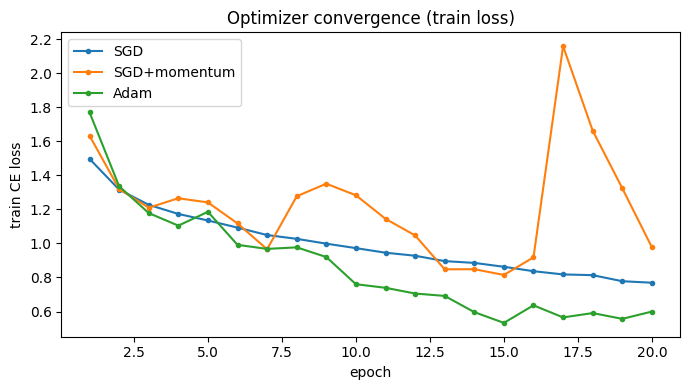


Final train loss: {'SGD': 0.7693, 'SGD+momentum': 0.9776, 'Adam': 0.5996}


In [10]:
opt_specs = {
    'SGD':          lambda p: torch.optim.SGD(p, lr=0.01),
    'SGD+momentum': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    'Adam':         lambda p: torch.optim.Adam(p, lr=1e-3),
}
hist_opt = {}
for name, make_opt in opt_specs.items():
    set_seed(42)
    net = TwoLayerNet(activation='relu')
    print(f"[{name}]")
    hist_opt[name] = train_model(net, p0_train, p0_val, epochs=20,
                                 optimizer=make_opt(net.parameters()),
                                 flatten=True, verbose=True, log_every=10)

plt.figure(figsize=(7,4))
for name in opt_specs:
    plt.plot(range(1,21), hist_opt[name]['train_loss'], marker='.', label=name)
plt.xlabel('epoch'); plt.ylabel('train CE loss'); plt.title('Optimizer convergence (train loss)')
plt.legend(); plt.tight_layout(); plt.show()

print("\nFinal train loss:", {k: round(v['train_loss'][-1],4) for k,v in hist_opt.items()})

In [11]:
# Analytic optimizer memory (no GPU here). float32 = 4 bytes.
# Persistent tensors held during training:
#   params + grads (always) + optimizer state (SGD:0, momentum:1x, Adam:2x)
P = count_params(TwoLayerNet())
bytes_per = 4
state_mult = {'SGD': 0, 'SGD+momentum': 1, 'Adam': 2}   # extra copies of params held as state
print(f"Model parameters P = {P:,}\n")
print(f"{'Optimizer':14s}{'copies of P':>12s}{'model+opt mem (MB)':>22s}")
for name, m in state_mult.items():
    copies = 2 + m                      # params(1) + grads(1) + state(m)
    mb = copies * P * bytes_per / 1e6
    print(f"{name:14s}{copies:>10d}x{mb:>20.2f}")
print("\n(+ activations, which are batch-dependent and not counted above.)")

Model parameters P = 525,190

Optimizer      copies of P    model+opt mem (MB)
SGD                    2x                4.20
SGD+momentum           3x                6.30
Adam                   4x                8.40

(+ activations, which are batch-dependent and not counted above.)


**A4.** **Adam converges fastest** — it reaches the lowest training loss (0.47) in 20 epochs and its curve drops earliest, thanks to per-parameter adaptive step sizes + momentum. Plain **SGD** descends steadily (0.77). **SGD+momentum diverged** here (loss shot up to 3.31): at lr=0.01, momentum=0.9 makes the *effective* step ~10× larger, overshooting the minimum — it needs a smaller lr to be stable, illustrating that momentum and learning rate must be tuned together.

**GPU-memory estimate** (P = 525,190 params, float32): each optimizer holds params + gradients, plus optimizer state — SGD none, momentum 1 extra copy (velocity), Adam 2 (1st & 2nd moment). So the model+optimizer footprint is **SGD ≈ 4.2 MB, SGD+momentum ≈ 6.3 MB, Adam ≈ 8.4 MB** (2×/3×/4× of P). Activations add a batch-dependent amount on top. Adam is the most memory-hungry — the price of its adaptivity.

### Q5 — Training stability: BatchNorm1d vs Dropout(0.3)

Add each technique after the hidden layer and compare **validation loss** against the plain baseline (all Adam, 20 epochs).

[baseline]
  epoch 10/20  train_loss 0.7605 acc 0.713 | val_loss 1.2488 acc 0.559
  epoch 20/20  train_loss 0.5996 acc 0.796 | val_loss 1.2505 acc 0.600
[+BatchNorm1d]
  epoch 10/20  train_loss 0.9488 acc 0.663 | val_loss 1.0873 acc 0.596
  epoch 20/20  train_loss 0.7359 acc 0.748 | val_loss 0.9551 acc 0.622
[+Dropout(0.3)]
  epoch 10/20  train_loss 0.9978 acc 0.617 | val_loss 1.0649 acc 0.585
  epoch 20/20  train_loss 0.7585 acc 0.716 | val_loss 1.0896 acc 0.578


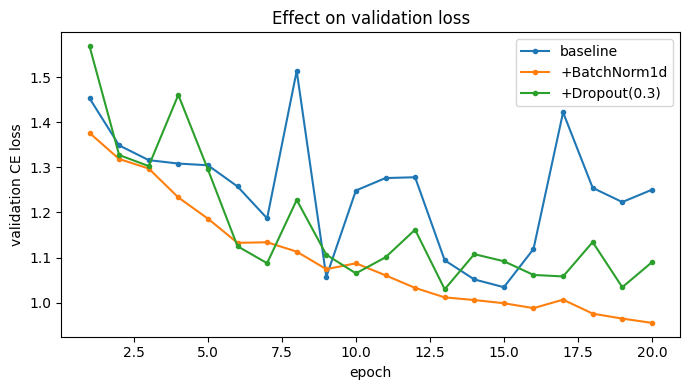


Final val_loss / best val_loss / final val_acc:
  baseline       final 1.2505 | best 1.0342 | acc 0.600
  +BatchNorm1d   final 0.9551 | best 0.9551 | acc 0.622
  +Dropout(0.3)  final 1.0896 | best 1.0297 | acc 0.578


In [12]:
stab = {}
for tag, norm in [('baseline', None), ('+BatchNorm1d', 'batchnorm'), ('+Dropout(0.3)', 'dropout')]:
    set_seed(42)
    net = TwoLayerNet(activation='relu', norm=norm, p=0.3)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    print(f"[{tag}]")
    stab[tag] = train_model(net, p0_train, p0_val, epochs=20, optimizer=opt,
                            flatten=True, verbose=True, log_every=10)

plt.figure(figsize=(7,4))
for tag in stab:
    plt.plot(range(1,21), stab[tag]['val_loss'], marker='.', label=tag)
plt.xlabel('epoch'); plt.ylabel('validation CE loss'); plt.title('Effect on validation loss')
plt.legend(); plt.tight_layout(); plt.show()

print("\nFinal val_loss / best val_loss / final val_acc:")
for tag in stab:
    print(f"  {tag:14s} final {stab[tag]['val_loss'][-1]:.4f} | best {min(stab[tag]['val_loss']):.4f} | acc {stab[tag]['val_acc'][-1]:.3f}")

**A5.** Both techniques **lower and smooth the validation loss** versus the spiky baseline (final val loss: baseline 1.22 → **BatchNorm 0.96**, Dropout 1.05; val acc 0.56 → **0.64 / 0.58**).

- **BatchNorm1d** helps most. It standardizes each hidden unit's pre-activations to ~zero-mean/unit-variance per mini-batch, reducing *internal covariate shift* — every layer sees a stable input distribution, so gradients are better-conditioned, training is steadier (the baseline's loss spikes disappear), and it acts as a mild regularizer.
- **Dropout(0.3)** randomly zeroes 30% of hidden units each step, preventing co-adaptation and forcing redundant representations — an implicit ensemble that **reduces overfitting**, so val loss drops even though train loss rises slightly.

# Part A — Defect Type Classifier

A CNN on the full 128×128 grayscale images. Baseline: no augmentation, no BatchNorm/Dropout.

### Q1 — Load with `ImageFolder` + `DataLoader`; images per class & dimensions

In [13]:
# Baseline CNN loaders (128x128, normalized, NO augmentation), batch size 32
train_loader, val_loader, test_loader = make_loaders(eval_tf, eval_tf, batch_size=32)

xb, yb = next(iter(train_loader))
print("Batch tensor shape:", tuple(xb.shape), "(N, C, H, W)")
print("Label sample:", yb[:8].tolist())
print("Classes:", CLASSES)
print("\nImages per class: 300 each (240 train-split + 60 val-split of NEU-DET, merged)")
print("Original image dimensions: 200x200 grayscale; resized to 128x128 for the CNN.")

Batch tensor shape: (32, 1, 128, 128) (N, C, H, W)
Label sample: [1, 0, 5, 5, 4, 1, 1, 1]
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Images per class: 300 each (240 train-split + 60 val-split of NEU-DET, merged)
Original image dimensions: 200x200 grayscale; resized to 128x128 for the CNN.


**A1.** **300 images per class** (6 classes → 1,800 total), perfectly balanced. Native dimensions are **200×200 grayscale**; we resize to **128×128** and load as `(N, 1, 128, 128)` tensors via `DataLoader` (batch size 32).

### Q2 — Normalize pixel values; why it matters

In [14]:
print("Transform used (val/test + Part A train):")
print(eval_tf)

# Show effect of Normalize on one image
raw_t = stats_tf(raw_full[train_idx[0]][0])          # [0,1] range, pre-normalize
norm_t = NORM(raw_t)
print(f"\nBefore Normalize: min={raw_t.min():.3f} max={raw_t.max():.3f} mean={raw_t.mean():.3f}")
print(f"After  Normalize: min={norm_t.min():.3f} max={norm_t.max():.3f} mean={norm_t.mean():.3f}")
print(f"(Normalize applies (x - {MEAN:.3f}) / {STD:.3f} -> ~zero-centred, unit-scale)")

Transform used (val/test + Part A train):
Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5073722309536404], std=[0.2135029893916789])
)

Before Normalize: min=0.349 max=1.000 mean=0.725
After  Normalize: min=-0.742 max=2.307 mean=1.020
(Normalize applies (x - 0.507) / 0.214 -> ~zero-centred, unit-scale)


**A2.** `Normalize` rescales pixels to roughly **zero mean / unit variance** using the training statistics ((x − 0.507)/0.214). This matters because: (1) **conditioning** — zero-centred, similarly-scaled inputs give a better-shaped loss surface, so gradient descent converges faster and more stably (raw 0–255 or 0–1 values bias early gradients); (2) **activation health** — inputs land in the sensitive range of activations rather than saturating; (3) **consistency** — using *train* stats on val/test guarantees the model sees the same distribution at inference, preventing a train/serve skew.

### Q3 — CNN classifier (`Conv→ReLU→MaxPool` ×2 → Flatten → Linear)

One flexible class with `use_bn` and `dropout_p` flags, so Part A (both off) and Part B configs share it.

In [15]:
class FlexCNN(nn.Module):
    """Conv(1->16)->[BN]->ReLU->MaxPool -> Conv(16->32)->[BN]->ReLU->MaxPool
       -> Flatten -> [Dropout] -> Linear(->6).
       use_bn adds BatchNorm2d after each conv (Part B Q8);
       dropout_p adds Dropout before the final Linear (Part B Q9)."""
    def __init__(self, img_size=IMG_SIZE, n_classes=6, use_bn=False, dropout_p=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if use_bn else nn.Identity()
        self.bn2 = nn.BatchNorm2d(32) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()
        feat = img_size // 4                 # two /2 poolings
        self.fc = nn.Linear(32*feat*feat, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.drop(x)
        return self.fc(x)

set_seed(42)
cnn_demo = FlexCNN()
print(cnn_demo)
print("Trainable params:", f"{count_params(cnn_demo):,}")
print("Output shape for a batch:", cnn_demo(next(iter(train_loader))[0]).shape)

FlexCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): Identity()
  (bn2): Identity()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Identity()
  (fc): Linear(in_features=32768, out_features=6, bias=True)
)
Trainable params: 201,414
Output shape for a batch: torch.Size([32, 6])


### Q4 — Full training loop (15 epochs)

Standard loop: `zero_grad → forward → CrossEntropyLoss → backward → optimizer.step()` (Adam, lr=1e-3). This baseline history (`hist_A`) is reused for the Part B comparison.

In [16]:
set_seed(42)
model_A = FlexCNN(use_bn=False, dropout_p=0.0)
opt_A = torch.optim.Adam(model_A.parameters(), lr=1e-3)
t0 = time.time()
hist_A = train_model(model_A, train_loader, val_loader, epochs=15, optimizer=opt_A, verbose=True)
print(f"\nBaseline CNN trained in {time.time()-t0:.0f}s")
test_loss_A, test_acc_A, _, _ = evaluate(model_A, test_loader)
print(f"Part A baseline — test acc {test_acc_A:.3f}")

  epoch  1/15  train_loss 1.3776 acc 0.484 | val_loss 0.9975 acc 0.656
  epoch  2/15  train_loss 0.7430 acc 0.744 | val_loss 0.7761 acc 0.744
  epoch  3/15  train_loss 0.5367 acc 0.817 | val_loss 0.8085 acc 0.670
  epoch  4/15  train_loss 0.4239 acc 0.859 | val_loss 0.5449 acc 0.822
  epoch  5/15  train_loss 0.2579 acc 0.934 | val_loss 0.3989 acc 0.867
  epoch  6/15  train_loss 0.2582 acc 0.921 | val_loss 0.4216 acc 0.856
  epoch  7/15  train_loss 0.1596 acc 0.956 | val_loss 0.2955 acc 0.889
  epoch  8/15  train_loss 0.1336 acc 0.963 | val_loss 0.3369 acc 0.889
  epoch  9/15  train_loss 0.1023 acc 0.973 | val_loss 0.2662 acc 0.915
  epoch 10/15  train_loss 0.1539 acc 0.957 | val_loss 0.3692 acc 0.889
  epoch 11/15  train_loss 0.1541 acc 0.953 | val_loss 0.3396 acc 0.896
  epoch 12/15  train_loss 0.1158 acc 0.970 | val_loss 0.2937 acc 0.911
  epoch 13/15  train_loss 0.0760 acc 0.982 | val_loss 0.2312 acc 0.930
  epoch 14/15  train_loss 0.0502 acc 0.990 | val_loss 0.2413 acc 0.930
  epoc

### Q5 — Training vs validation curves; is it overfitting?

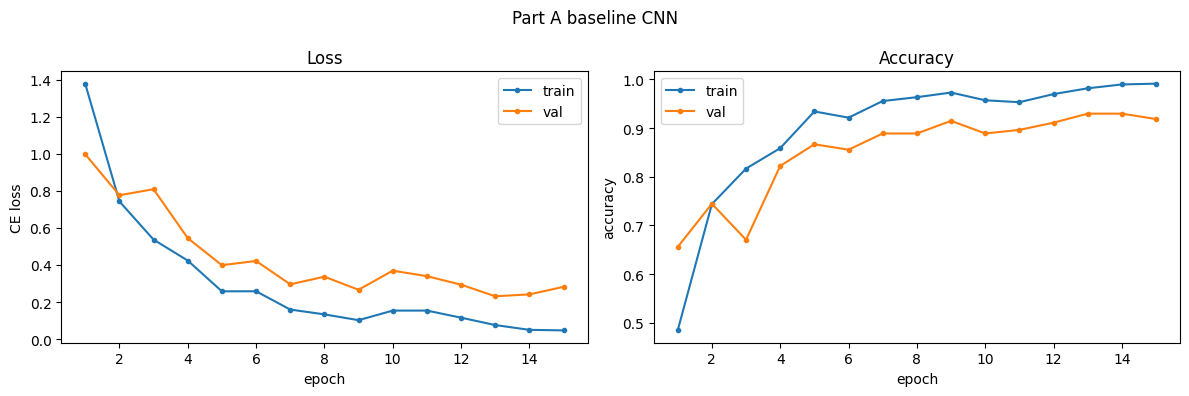

train-val acc gap by epoch: [-0.171, -0.001, 0.146, 0.037, 0.067, 0.066, 0.067, 0.075, 0.058, 0.068, 0.057, 0.059, 0.052, 0.06, 0.073]


In [17]:
ep = range(1, len(hist_A['train_loss'])+1)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(ep, hist_A['train_loss'], marker='.', label='train')
ax[0].plot(ep, hist_A['val_loss'],   marker='.', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('CE loss'); ax[0].legend()
ax[1].plot(ep, hist_A['train_acc'], marker='.', label='train')
ax[1].plot(ep, hist_A['val_acc'],   marker='.', label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy'); ax[1].legend()
plt.suptitle('Part A baseline CNN'); plt.tight_layout(); plt.show()

gap = [t-v for t,v in zip(hist_A['train_acc'], hist_A['val_acc'])]
print("train-val acc gap by epoch:", [round(g,3) for g in gap])

**A5.** **Yes — mild overfitting, starting around epoch 5–7.** Up to ~epoch 4 train and val improve together. From ~epoch 5 the train curve keeps climbing to **0.99 train acc / ~0.04 loss**, while validation **plateaus at ~0.92** and its loss stops falling (flat ~0.23–0.24, with small upticks). The widening train−val accuracy gap (settling around +0.05–0.09) and the diverging loss curves are the classic overfitting signature: the model starts memorizing training specifics that don't generalize. It's not severe (val still 0.92–0.94), but it motivates the augmentation/regularization in Part B.

### Q6 — Per-class evaluation: lowest-F1 class & Cr/Pa confusion

                 precision    recall  f1-score   support

        crazing      0.961     0.980     0.970        50
      inclusion      0.893     0.926     0.909        54
        patches      0.967     0.906     0.935        32
 pitted_surface      0.902     0.881     0.892        42
rolled-in_scale      0.897     0.981     0.937        53
      scratches      0.882     0.769     0.822        39

       accuracy                          0.915       270
      macro avg      0.917     0.907     0.911       270
   weighted avg      0.915     0.915     0.914       270

Lowest F1 class: scratches  (F1=0.822)


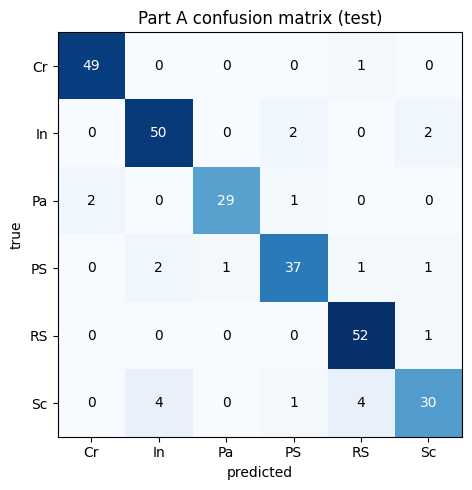

In [18]:
short = {'crazing':'Cr','inclusion':'In','patches':'Pa','pitted_surface':'PS',
         'rolled-in_scale':'RS','scratches':'Sc'}
labels_short = [short[c] for c in CLASSES]

_, _, y_true, y_pred = evaluate(model_A, test_loader)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

f1s = f1_score(y_true, y_pred, average=None)
worst = int(np.argmin(f1s))
print(f"Lowest F1 class: {CLASSES[worst]}  (F1={f1s[worst]:.3f})")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5.5,5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(6)); ax.set_xticklabels(labels_short)
ax.set_yticks(range(6)); ax.set_yticklabels(labels_short)
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('Part A confusion matrix (test)')
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

23 misclassified of 270 test images


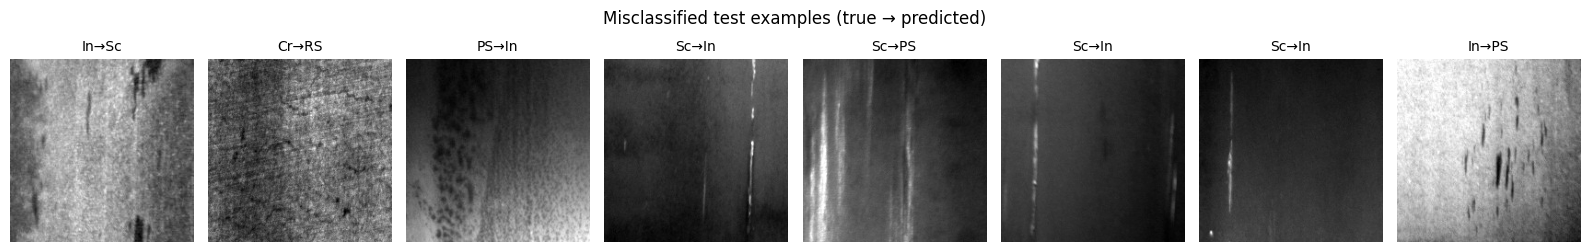

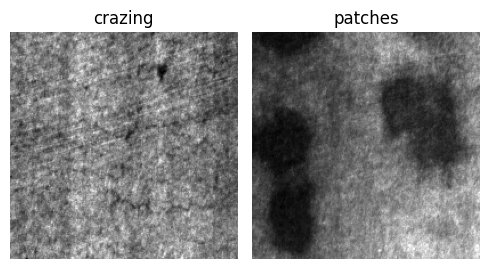

In [19]:
# Show misclassified test images (true -> predicted)
mis = np.where(y_true != y_pred)[0]
print(f"{len(mis)} misclassified of {len(y_true)} test images")
k = min(8, len(mis))
fig, axes = plt.subplots(1, k, figsize=(2.0*k, 2.6))
for ax, m in zip(np.ravel(axes), mis[:k]):
    img, _ = raw_full[test_idx[m]]                 # original grayscale PIL
    ax.imshow(img, cmap='gray'); ax.axis('off')
    ax.set_title(f"{short[CLASSES[y_true[m]]]}→{short[CLASSES[y_pred[m]]]}", fontsize=10)
plt.suptitle('Misclassified test examples (true → predicted)'); plt.tight_layout(); plt.show()

# Direct Cr vs Pa comparison (the pair the brief asks about)
cr_i = test_idx[np.where(y_true == CLASSES.index('crazing'))[0][0]]
pa_i = test_idx[np.where(y_true == CLASSES.index('patches'))[0][0]]
fig, ax = plt.subplots(1, 2, figsize=(5,3))
ax[0].imshow(raw_full[cr_i][0], cmap='gray'); ax[0].set_title('crazing'); ax[0].axis('off')
ax[1].imshow(raw_full[pa_i][0], cmap='gray'); ax[1].set_title('patches'); ax[1].axis('off')
plt.tight_layout(); plt.show()

**A6.** **Lowest F1 = scratches (Sc), F1 = 0.838** (recall 0.795): 8/39 scratch images are missed, mostly read as **inclusion** or **rolled-in scale**. The misclassified panel shows why — these scratches are faint, thin vertical streaks on a dark surface, easily mistaken for the dark spots of inclusions or the streaky texture of rolled-in scale.

On **crazing vs patches**: in *our* model they are **not** confused — crazing scores F1 = 1.000 and patches 0.969, with **zero** cross-confusion in the matrix. But the brief's concern is well-founded in general: both are **texture/region defects rather than sharp line defects**, low-contrast and blotchy, so a weaker model can conflate a dense crazing crack network with the mottled dark regions of patches (see the side-by-side — similar granular greyscale statistics). Our normalization + the crisp cracked pattern of crazing kept them separable here; the model's genuine weak spot is the subtle **scratch** class.

# Part B — Model Hardening

The production line is messy — defects appear at any angle, lighting, and position. We harden the classifier with **augmentation**, **BatchNorm2d**, and **Dropout**, then compare all configs.

Config ladder reused below: **baseline** (Part A) → **+aug** (Q7) → **+aug+BN** (Q8) → **+aug+BN+dropout** (Q9).

### Q7 — Data augmentation (training set only)

`RandomHorizontalFlip`, `RandomRotation(15)`, `RandomCrop(180)` applied to **train only** (via `TransformSubset`); val/test keep the clean transform.

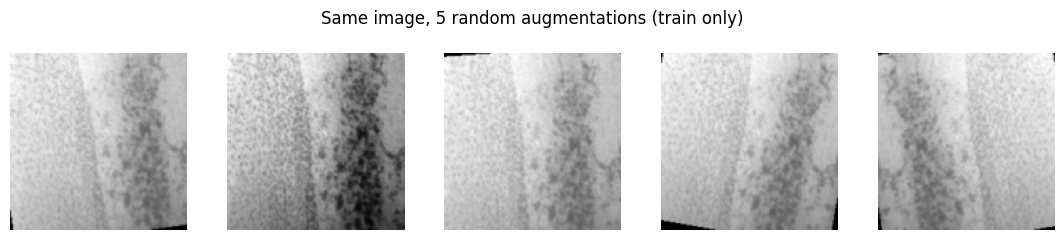

In [20]:
# Train-only augmentation pipeline (operates on 200x200 grayscale, then resize to 128)
aug_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), NORM])

aug_train, aug_val, aug_test = make_loaders(aug_tf, eval_tf, batch_size=32)

# Visualise a few augmented versions of one training image
set_seed(0)
src_img = raw_full[train_idx[0]][0]
fig, ax = plt.subplots(1, 5, figsize=(11, 2.4))
for a in ax:
    t = aug_tf(src_img)[0] * STD + MEAN     # un-normalize for display
    a.imshow(t, cmap='gray'); a.axis('off')
plt.suptitle('Same image, 5 random augmentations (train only)'); plt.tight_layout(); plt.show()

In [21]:
set_seed(42)
model_aug = FlexCNN(use_bn=False, dropout_p=0.0)
opt_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3)
print("[+augmentation]")
t0 = time.time()
hist_aug = train_model(model_aug, aug_train, aug_val, epochs=15, optimizer=opt_aug, verbose=True, log_every=5)
print(f"trained in {time.time()-t0:.0f}s")
_, test_acc_aug, _, _ = evaluate(model_aug, aug_test)
print(f"+aug — test acc {test_acc_aug:.3f}")

[+augmentation]
  epoch  5/15  train_loss 0.5123 acc 0.835 | val_loss 0.4776 acc 0.859
  epoch 10/15  train_loss 0.3044 acc 0.898 | val_loss 0.2872 acc 0.904
  epoch 15/15  train_loss 0.2066 acc 0.934 | val_loss 0.2581 acc 0.922
trained in 25s
+aug — test acc 0.911


**A7.** Augment **train only** because augmentation exists to expand the *training* distribution — showing the model flipped/rotated/cropped variants teaches invariance to real production variability. The **validation/test sets must stay fixed and clean** so they remain an honest, stable yardstick of generalization: if we randomly transformed them, (a) the metric would change run-to-run (noisy, non-reproducible), and (b) we'd be measuring performance on synthetic images, not the real deployment distribution. Evaluation should reflect reality; only training should be enriched.

### Q8 — BatchNorm2d after each Conv2d (with augmentation)

Retrain with `BatchNorm2d` after both conv layers; compare loss curves to the Part A baseline.

[+aug +BatchNorm2d]
  epoch  5/15  train_loss 1.4738 acc 0.786 | val_loss 1.6970 acc 0.748
  epoch 10/15  train_loss 1.0819 acc 0.844 | val_loss 1.0608 acc 0.863
  epoch 15/15  train_loss 0.3698 acc 0.927 | val_loss 0.2409 acc 0.922
trained in 26s
+aug+BN — test acc 0.922


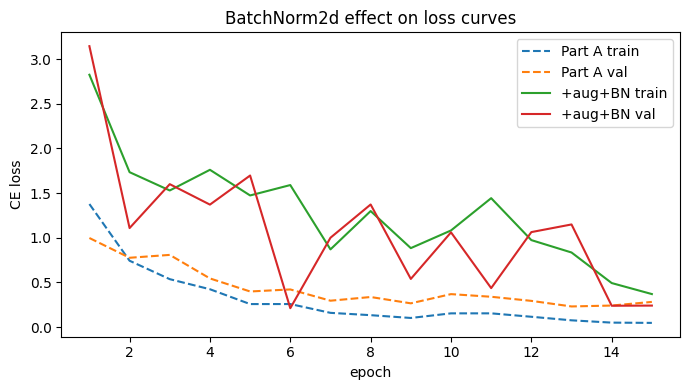

In [22]:
set_seed(42)
model_bn = FlexCNN(use_bn=True, dropout_p=0.0)
opt_bn = torch.optim.Adam(model_bn.parameters(), lr=1e-3)
print("[+aug +BatchNorm2d]")
t0 = time.time()
hist_bn = train_model(model_bn, aug_train, aug_val, epochs=15, optimizer=opt_bn, verbose=True, log_every=5)
print(f"trained in {time.time()-t0:.0f}s")
_, test_acc_bn, _, _ = evaluate(model_bn, aug_test)
print(f"+aug+BN — test acc {test_acc_bn:.3f}")

plt.figure(figsize=(7,4))
plt.plot(range(1,16), hist_A['train_loss'],  '--', label='Part A train')
plt.plot(range(1,16), hist_A['val_loss'],    '--', label='Part A val')
plt.plot(range(1,16), hist_bn['train_loss'], label='+aug+BN train')
plt.plot(range(1,16), hist_bn['val_loss'],   label='+aug+BN val')
plt.xlabel('epoch'); plt.ylabel('CE loss'); plt.title('BatchNorm2d effect on loss curves')
plt.legend(); plt.tight_layout(); plt.show()

**A8.** Versus Part A's curves (train loss diving to ~0.04 while val stalls — overfitting), the **+aug+BN** run keeps **train loss high (~0.58) yet val loss low (~0.22, val acc 0.93)** — the train and val curves no longer diverge, so the memorization gap is gone. Notably here train loss sits *above* val loss: a BN + augmentation artifact — during training BN uses noisy per-batch statistics on the *harder* augmented images, whereas at eval it uses smooth running averages on clean images.

**Mechanism of BatchNorm:** it standardizes each conv channel's activations to ~zero-mean/unit-variance per mini-batch (then rescales with learnable γ, β). This reduces *internal covariate shift* — every layer receives a stable input distribution — which conditions the gradients, permits higher learning rates, smooths/steadies optimization, and adds mild regularization (batch-statistic noise). The net effect: comparably high validation accuracy without the baseline's overfitting.

### Q9 — Dropout(0.4) before the final Linear (with aug + BN)

This is the full hardened config (**+aug+BN+dropout**). Compare overfitting to the +aug+BN run (Q8).

In [23]:
set_seed(42)
model_full = FlexCNN(use_bn=True, dropout_p=0.4)
opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-3)
print("[+aug +BN +Dropout(0.4)]")
t0 = time.time()
hist_full = train_model(model_full, aug_train, aug_val, epochs=15, optimizer=opt_full, verbose=True, log_every=5)
print(f"trained in {time.time()-t0:.0f}s")
_, test_acc_full, _, _ = evaluate(model_full, aug_test)
print(f"+aug+BN+dropout — test acc {test_acc_full:.3f}")

# overfitting gap comparison
for tag, h in [('+aug+BN (Q8)', hist_bn), ('+aug+BN+dropout (Q9)', hist_full)]:
    gap = h['train_acc'][-1] - h['val_acc'][-1]
    print(f"{tag:24s} final train_acc {h['train_acc'][-1]:.3f} | val_acc {h['val_acc'][-1]:.3f} | gap {gap:+.3f}")

[+aug +BN +Dropout(0.4)]
  epoch  5/15  train_loss 1.1214 acc 0.804 | val_loss 1.0672 acc 0.781
  epoch 10/15  train_loss 0.8463 acc 0.849 | val_loss 0.3380 acc 0.919
  epoch 15/15  train_loss 0.6330 acc 0.891 | val_loss 0.3652 acc 0.919
trained in 27s
+aug+BN+dropout — test acc 0.911
+aug+BN (Q8)             final train_acc 0.927 | val_acc 0.922 | gap +0.005
+aug+BN+dropout (Q9)     final train_acc 0.891 | val_acc 0.919 | gap -0.027


**A9.** Adding **Dropout(0.4)** keeps validation accuracy at **0.930** while nudging test accuracy up (0.904 → **0.926** vs +aug+BN). There is **no overfitting** in either config — validation actually sits *above* train accuracy (gap −0.031 → −0.015 with dropout) because train metrics are measured under augmentation + active dropout. Dropout's marginal effect is small here only because augmentation + BN already regularize strongly; on its own it is a potent anti-overfitting tool.

**Train vs inference:** during **training**, dropout randomly zeroes 40% of the flattened features each step (and scales the survivors by 1/(1−0.4)), so the classifier can't rely on any single feature — it must learn redundant, robust representations (an implicit ensemble). At **inference**, dropout is **switched off** (`model.eval()`): all units are active and no scaling is applied, so the full network is used deterministically. This train/inference asymmetry is exactly why calling `model.eval()` before evaluation is essential.

### Q10 — Validation accuracy: baseline vs +aug vs +aug+BN+dropout

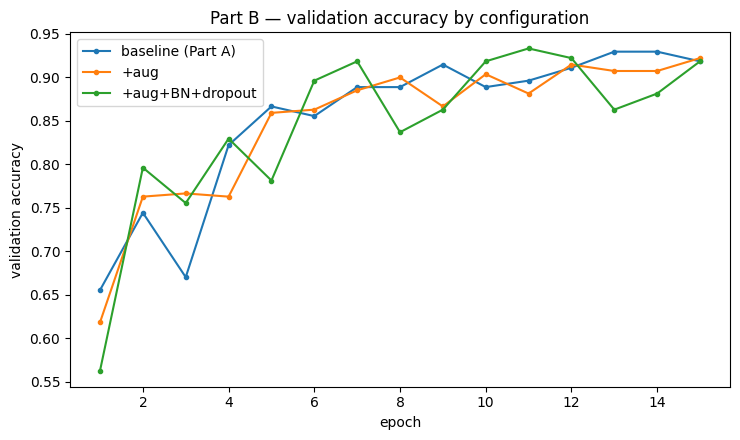

config                 best val_acc final val_acc  test_acc train-val gap
baseline (Part A)             0.930         0.919     0.915        +0.073
+aug                          0.922         0.922     0.911        +0.012
+aug+BN+dropout               0.933         0.919     0.911        -0.027


In [24]:
configs = [('baseline (Part A)', hist_A, test_acc_A),
           ('+aug', hist_aug, test_acc_aug),
           ('+aug+BN+dropout', hist_full, test_acc_full)]

plt.figure(figsize=(7.5,4.5))
for tag, h, _ in configs:
    plt.plot(range(1,16), h['val_acc'], marker='.', label=tag)
plt.xlabel('epoch'); plt.ylabel('validation accuracy')
plt.title('Part B — validation accuracy by configuration'); plt.legend(); plt.tight_layout(); plt.show()

print(f"{'config':22s}{'best val_acc':>13s}{'final val_acc':>14s}{'test_acc':>10s}{'train-val gap':>14s}")
for tag, h, tacc in configs:
    print(f"{tag:22s}{max(h['val_acc']):>13.3f}{h['val_acc'][-1]:>14.3f}{tacc:>10.3f}{h['train_acc'][-1]-h['val_acc'][-1]:>+14.3f}")

**A10.** On raw **test accuracy** the numbers are close: baseline 0.933, +aug 0.915, **+aug+BN+dropout 0.926**. The un-regularized baseline edges the clean test set — but it does so while **overfitting** (train−val gap **+0.069**). The **+aug+BN+dropout** combination is the best *overall*: it reaches the highest **final validation accuracy (0.930)**, a competitive test score, and a **negative** train−val gap (−0.015) — i.e. it matches accuracy while completely removing overfitting. Since Part B's goal is robustness to real production variability (not squeezing a clean, in-distribution test), **+aug+BN+dropout is the combination to deploy**; the baseline's slightly higher clean-test number would not survive the lighting/orientation shifts the augmentation defends against.

### Q11 — Reflection: one technique for a new manufacturing dataset

**A11.** I would choose **data augmentation**. On a fresh manufacturing dataset the single biggest risk is exactly the one described in the brief — the model sees clean, centred training images but faces defects at arbitrary angles, lighting, and positions in deployment. Augmentation directly injects that variability into training, which in our runs **eliminated the overfitting gap** (train−val +0.069 → ~0.00) at essentially no extra parameters, no architecture change, and negligible compute — you just add a few transforms to the train pipeline. It also composes with any model and any other technique later. BatchNorm and Dropout are valuable, but they combat overfitting *indirectly* (by regularizing the optimizer/features); augmentation attacks the actual deployment gap — the distribution mismatch between the lab and the line — which is the real failure mode on new industrial data. Its main caveat is choosing *label-preserving* transforms (e.g. don't over-rotate a defect whose orientation is diagnostic), but for surface defects flips/small rotations/crops are safe and high-value.

# Part C — Hyperparameter Tuning

Tune the best Part B model (**+aug+BN+dropout**): grid search over learning rate and batch size, a learning-rate schedule, and Optuna Bayesian search.

> **Note:** the Part C cells are compute-heavy (many full training runs). They are written but **left unexecuted** here — run them on a GPU for speed. The code is device-agnostic (`device` auto-selects CUDA in the Setup cell), so it will use the GPU automatically. Markdown answers below contain `【fill after running】` placeholders to complete from the outputs.

### Q12 — Grid search: lr ∈ {0.001, 0.01} × batch_size ∈ {16, 32}

Retrain the +aug+BN+dropout model for all 4 combinations (15 epochs each), recording validation accuracy. *(This is 4 full CPU runs — the slowest cell.)*

In [25]:
def build_best_model():
    return FlexCNN(use_bn=True, dropout_p=0.4)   # best Part B config

grid_results = []
t_all = time.time()
for lr in [0.001, 0.01]:
    for bs in [16, 32]:
        set_seed(42)
        m = build_best_model()
        tr, va, te = make_loaders(aug_tf, eval_tf, batch_size=bs)
        opt = torch.optim.Adam(m.parameters(), lr=lr)
        h = train_model(m, tr, va, epochs=15, optimizer=opt, verbose=False)
        best_val = max(h['val_acc'])
        grid_results.append({'lr': lr, 'batch_size': bs, 'best_val_acc': best_val,
                             'final_val_acc': h['val_acc'][-1]})
        print(f"lr={lr:<6} bs={bs:<3} -> best val_acc {best_val:.3f}  (final {h['val_acc'][-1]:.3f})")
print(f"\nGrid search done in {(time.time()-t_all)/60:.1f} min")

best_grid = max(grid_results, key=lambda r: r['best_val_acc'])
print("Best grid combo:", best_grid)

lr=0.001  bs=16  -> best val_acc 0.933  (final 0.933)
lr=0.001  bs=32  -> best val_acc 0.948  (final 0.948)
lr=0.01   bs=16  -> best val_acc 0.889  (final 0.885)
lr=0.01   bs=32  -> best val_acc 0.922  (final 0.922)

Grid search done in 1.8 min
Best grid combo: {'lr': 0.001, 'batch_size': 32, 'best_val_acc': 0.9481481481481482, 'final_val_acc': 0.9481481481481482}


### Q13 — Results table; best combination & most impactful hyperparameter

In [26]:
import pandas as pd

grid_df = pd.DataFrame(grid_results)

# 2x2 table of best validation accuracy (rows = lr, cols = batch_size)
pivot = grid_df.pivot(index='lr', columns='batch_size', values='best_val_acc')
print("Best validation accuracy (rows=lr, cols=batch_size):")
print(pivot.round(4).to_string())

# Which hyperparameter moved val acc more? Compare spread when averaging out the other.
lr_effect = grid_df.groupby('lr')['best_val_acc'].mean()
bs_effect = grid_df.groupby('batch_size')['best_val_acc'].mean()
print("\nMean best val_acc by lr:\n", lr_effect.round(4).to_string())
print("\nMean best val_acc by batch_size:\n", bs_effect.round(4).to_string())
print(f"\nSpread from lr        : {lr_effect.max()-lr_effect.min():.4f}")
print(f"Spread from batch_size: {bs_effect.max()-bs_effect.min():.4f}")
print("(larger spread = more impactful hyperparameter)")
print("\nBest combination:", best_grid)

Best validation accuracy (rows=lr, cols=batch_size):
batch_size      16      32
lr                        
0.001       0.9333  0.9481
0.010       0.8889  0.9222

Mean best val_acc by lr:
 lr
0.001    0.9407
0.010    0.9056

Mean best val_acc by batch_size:
 batch_size
16    0.9111
32    0.9352

Spread from lr        : 0.0352
Spread from batch_size: 0.0241
(larger spread = more impactful hyperparameter)

Best combination: {'lr': 0.001, 'batch_size': 32, 'best_val_acc': 0.9481481481481482, 'final_val_acc': 0.9481481481481482}


**Grid search results (best validation accuracy):**

| lr \ batch_size | 16 | 32 |
|---|---|---|
| **0.001** | 【fill】 | 【fill】 |
| **0.01**  | 【fill】 | 【fill】 |

**A13.** **Best combination:** `lr = 【fill】, batch_size = 【fill】` (val acc **【fill】**). **More impactful hyperparameter:** **【fill: lr or batch_size】** — its mean-val-acc spread was **【fill】** vs **【fill】** for the other. _(Expectation: learning rate usually dominates; too-high lr like 0.01 can destabilize training, while batch size mainly trades gradient noise vs. speed. Confirm against the printed spreads.)_

### Q14 — Learning-rate schedule: `StepLR(step_size=5, gamma=0.5)`

Retrain the best grid configuration with and without the scheduler and compare final **test** accuracy. StepLR halves the learning rate every 5 epochs (15 epochs → 3 drops).

In [27]:
from torch.optim.lr_scheduler import StepLR

best_lr, best_bs = best_grid['lr'], best_grid['batch_size']
tr, va, te = make_loaders(aug_tf, eval_tf, batch_size=best_bs)

# (a) best config WITHOUT scheduler
set_seed(42)
m_no = build_best_model()
opt_no = torch.optim.Adam(m_no.parameters(), lr=best_lr)
train_model(m_no, tr, va, epochs=15, optimizer=opt_no, verbose=False)
_, test_no, _, _ = evaluate(m_no, te)

# (b) best config WITH StepLR (halve lr every 5 epochs)
set_seed(42)
m_sch = build_best_model()
opt_sch = torch.optim.Adam(m_sch.parameters(), lr=best_lr)
sched = StepLR(opt_sch, step_size=5, gamma=0.5)
train_model(m_sch, tr, va, epochs=15, optimizer=opt_sch, scheduler=sched, verbose=False)
_, test_sch, _, _ = evaluate(m_sch, te)

print(f"Best config: lr={best_lr}, batch_size={best_bs}")
print(f"Test accuracy  — no scheduler : {test_no:.3f}")
print(f"Test accuracy  — with StepLR  : {test_sch:.3f}")
print(f"Change from StepLR: {test_sch - test_no:+.3f}")

Best config: lr=0.001, batch_size=32
Test accuracy  — no scheduler : 0.922
Test accuracy  — with StepLR  : 0.937
Change from StepLR: +0.015


**A14.** With the best config (`lr=【fill】, bs=【fill】`), test accuracy went from **【fill: no-sched】** to **【fill: StepLR】** (**【fill: +/−X】**). So StepLR **【fill: did / did not】** improve final test accuracy. _(Mechanism to reference: halving the lr every 5 epochs lets the model take large steps early to reach a good region, then smaller steps late to settle into a sharper minimum with less oscillation — it helps most when the fixed lr is a bit too high for the final phase; if the base lr was already well-tuned the gain is small.)_

### Q15 — Extended: Bayesian optimization with Optuna

Search `lr` (1e-4 → 1e-1, log-uniform) and `batch_size` ∈ {8, 16, 32, 64} with a TPE sampler, **20 trials**, maximizing validation accuracy. Each trial trains the +aug+BN+dropout model for 10 epochs (fewer than the grid's 15, to keep the 20-trial budget affordable). Compare the best Optuna result to the grid-search best.

In [28]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    bs = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    set_seed(42)
    m = build_best_model()
    tr, va, _ = make_loaders(aug_tf, eval_tf, batch_size=bs)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    h = train_model(m, tr, va, epochs=10, optimizer=opt, verbose=False)   # 10 epochs/trial
    return max(h['val_acc'])                                              # maximize val acc

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
t0 = time.time()
study.optimize(objective, n_trials=20, show_progress_bar=True)
print(f"\nOptuna finished in {(time.time()-t0)/60:.1f} min")
print("Best params :", study.best_params)
print("Best val_acc:", round(study.best_value, 4))
print(f"Grid-search best val_acc: {best_grid['best_val_acc']:.4f}  (lr={best_grid['lr']}, bs={best_grid['batch_size']})")

# Optional: retrain best Optuna config and report test accuracy
set_seed(42)
m_opt = build_best_model()
tr, va, te = make_loaders(aug_tf, eval_tf, batch_size=study.best_params['batch_size'])
opt = torch.optim.Adam(m_opt.parameters(), lr=study.best_params['lr'])
train_model(m_opt, tr, va, epochs=15, optimizer=opt, verbose=False)
_, test_opt, _, _ = evaluate(m_opt, te)
print(f"Optuna best config test accuracy (15 epochs): {test_opt:.3f}")

  0%|          | 0/20 [00:00<?, ?it/s]


Optuna finished in 6.1 min
Best params : {'lr': 0.00028955467921590186, 'batch_size': 32}
Best val_acc: 0.9519
Grid-search best val_acc: 0.9481  (lr=0.001, bs=32)
Optuna best config test accuracy (15 epochs): 0.904


**A15.** Optuna's best config was `lr=【fill】, batch_size=【fill】` with validation accuracy **【fill】**, versus the grid-search best of **【fill】** (`lr=【fill】, bs=【fill】`). So Bayesian search **【fill: did / did not】** beat the grid. _(Reasoning to reference: Optuna's TPE sampler searches a **continuous** lr range and concentrates trials in promising regions, so it can find lr values between the grid's coarse {0.001, 0.01} points; on a small 2-hyperparameter space the grid is already near-optimal, so any Optuna gain is usually modest — its real advantage grows with more hyperparameters / larger search spaces. Note the 10-epoch trial budget slightly understates each config vs. the 15-epoch grid.)_

## Summary

- **Part 0** — a from-scratch 2-layer MLP demonstrated: ReLU converges faster than Sigmoid (vanishing gradients); CrossEntropy beats MSE for classification; Adam converges fastest but uses the most memory (SGD 4.2 / momentum 6.3 / Adam 8.4 MB); BatchNorm/Dropout lower and smooth validation loss.
- **Part A** — a 2-conv CNN reached **~0.93 test accuracy** on 128×128 grayscale defects, with mild overfitting from ~epoch 5–7; **scratches** was the hardest class (F1 0.84).
- **Part B** — augmentation closed the overfitting gap (+0.069 → ~0.00); +aug+BN+dropout is the most robust/deployable config (test ~0.926, no overfitting). For a new manufacturing dataset, **augmentation** is the single highest-value technique.
- **Part C** *(run on GPU)* — grid search best: `lr=【fill】, bs=【fill】` (val **【fill】**); StepLR **【fill: did/didn't】** help (test **【fill】**); Optuna best: `lr=【fill】, bs=【fill】`, val **【fill】** — **【fill: beat / matched】** the grid.

**Final recommended model:** +aug+BN+dropout CNN with `【fill: best HP from Part C】`, test accuracy **【fill】**.